In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.model_selection import TimeSeriesSplit
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [4]:
file_path = Path(r"C:\Data_analysis\Thesis\Data\03_Training\Data_with_NaNs\df_BA_TotActPwr_BESS_AC_Panel1.parquet")

df = pd.read_parquet(file_path)

print("Shape:", df.shape)
df.head()

df = pd.read_parquet(file_path)

print("Shape:", df.shape)
df.head()

Shape: (33074, 26)
Shape: (33074, 26)


,BA_TotActPwr_BESS_AC_Panel1,BA_Soc,PV_WS_AirTemp,PV_WS_Radiation,PV_WS_RelHum,dayofweek,is_weekend,hour,month,dayofmonth,...,BA_TotActPwr_BESS_AC_Panel1_lag_1,BA_TotActPwr_BESS_AC_Panel1_lag_3,BA_TotActPwr_BESS_AC_Panel1_lag_12,BA_TotActPwr_BESS_AC_Panel1_lag_36,BA_TotActPwr_BESS_AC_Panel1_lag_288,BA_TotActPwr_BESS_AC_Panel1_roll_mean_12,BA_TotActPwr_BESS_AC_Panel1_roll_mean_36,BA_TotActPwr_BESS_AC_Panel1_roll_mean_288,BA_TotActPwr_BESS_AC_Panel1_roll_std_12,BA_TotActPwr_BESS_AC_Panel1_roll_std_36
Time,,,,,,,,,,,,,,,,,,,,,
2025-10-16 00:00:00,1.332,83.7,131.0,-4.2,84.5,3,0,0,10,16,...,1.347,1.926,1.633,1.049,1.630,1.440917,1.210694,2.219365,0.315719,0.258106
2025-10-16 00:05:00,1.635,83.6,131.0,-4.2,84.9,3,0,0,10,16,...,1.332,1.637,1.049,1.054,1.632,1.415833,1.218556,2.218330,0.310992,0.257349
2025-10-16 00:10:00,2.215,83.5,130.0,-4.1,85.1,3,0,0,10,16,...,1.635,1.347,1.052,1.050,1.633,1.464667,1.234694,2.218340,0.293680,0.264843
2025-10-16 00:15:00,2.509,83.4,129.0,-4.0,85.2,3,0,0,10,16,...,2.215,1.332,1.042,1.050,1.636,1.561583,1.267056,2.220361,0.334218,0.309107
2025-10-16 00:20:00,2.213,83.4,129.0,-3.9,85.4,3,0,0,10,16,...,2.509,1.635,1.047,1.042,1.634,1.683833,1.307583,2.223392,0.390456,0.369569


In [5]:
print(isinstance(df.index, pd.DatetimeIndex))  # should be True
print(df.index.is_monotonic_increasing)        # should be True
print(df.index.has_duplicates)                 # should be False

True
True
False


In [6]:
# =========================================================
# 1. DEFINE TARGET AND FEATURES
# =========================================================
# Change this to your actual target load column
target_col = "BA_TotActPwr_BESS_AC_Panel1"

# Safer: explicitly define feature columns if possible
# For now, this takes all columns except the target
feature_cols = [c for c in df.columns if c != target_col]

print("Target column:", target_col)
print("Number of features:", len(feature_cols))

# =========================================================
# 2. HORIZONS FOR 5-MIN DATA
# =========================================================

HORIZONS = {
    "1h": 12,
    "1d": 288
}

# =========================================================
# 3. METRICS
# =========================================================
def calc_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    mask = y_true != 0
    if mask.sum() > 0:
        mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
    else:
        mape = np.nan

    r2 = r2_score(y_true, y_pred)

    return {
        "MAE": mae,
        "RMSE": rmse,
        "MAPE_%": mape,
        "R2": r2
    }

# =========================================================
# 4. MAIN FUNCTION
# =========================================================
def train_rf_with_timeseries_split(
    df,
    target_col,
    feature_cols,
    horizon_steps,
    test_ratio=0.20,
    n_splits=5,
    random_state=42
):
    data = df.copy()

    # Create future target
    data["target_future"] = data[target_col].shift(-horizon_steps)

    # Drop rows where future target is missing
    data = data.dropna(subset=["target_future"])

    # Optional: if your features still have NaN, remove those rows for Random Forest
    data = data.dropna(subset=feature_cols)

    X = data[feature_cols]
    y = data["target_future"]

    # -----------------------------
    # Chronological final split
    # -----------------------------
    n_total = len(data)
    n_test = int(n_total * test_ratio)
    n_train = n_total - n_test

    X_train = X.iloc[:n_train]
    X_test  = X.iloc[n_train:]

    y_train = y.iloc[:n_train]
    y_test  = y.iloc[n_train:]

    print("\n" + "="*70)
    print(f"Horizon steps: {horizon_steps}")
    print(f"Total samples : {n_total}")
    print(f"Train samples : {len(X_train)}")
    print(f"Test samples  : {len(X_test)}")
    print(f"Train period  : {X_train.index.min()}  -->  {X_train.index.max()}")
    print(f"Test period   : {X_test.index.min()}  -->  {X_test.index.max()}")

    # -----------------------------
    # TimeSeriesSplit on TRAIN only
    # -----------------------------
    tscv = TimeSeriesSplit(n_splits=n_splits)

    fold_results = []

    for fold, (tr_idx, val_idx) in enumerate(tscv.split(X_train), start=1):
        X_tr = X_train.iloc[tr_idx]
        y_tr = y_train.iloc[tr_idx]
        X_val = X_train.iloc[val_idx]
        y_val = y_train.iloc[val_idx]

        model = RandomForestRegressor(
            n_estimators=300,
            max_depth=15,
            min_samples_split=10,
            min_samples_leaf=4,
            n_jobs=-1,
            random_state=random_state
        )

        model.fit(X_tr, y_tr)
        y_val_pred = model.predict(X_val)

        metrics = calc_metrics(y_val.values, y_val_pred)

        fold_results.append({
            "fold": fold,
            "train_start": X_tr.index.min(),
            "train_end": X_tr.index.max(),
            "val_start": X_val.index.min(),
            "val_end": X_val.index.max(),
            **metrics
        })

        print(
            f"Fold {fold}: "
            f"MAE={metrics['MAE']:.4f}, "
            f"RMSE={metrics['RMSE']:.4f}, "
            f"MAPE={metrics['MAPE_%']:.2f}%, "
            f"R2={metrics['R2']:.4f}"
        )

    cv_results = pd.DataFrame(fold_results)

    print("\nAverage CV metrics:")
    print(cv_results[["MAE", "RMSE", "MAPE_%", "R2"]].mean())

    # -----------------------------
    # Final model on full training set
    # -----------------------------
    final_model = RandomForestRegressor(
        n_estimators=300,
        max_depth=15,
        min_samples_split=10,
        min_samples_leaf=4,
        n_jobs=-1,
        random_state=random_state
    )

    final_model.fit(X_train, y_train)
    y_test_pred = final_model.predict(X_test)

    test_metrics = calc_metrics(y_test.values, y_test_pred)

    print("\nFinal Test Metrics:")
    print(test_metrics)

    predictions = pd.DataFrame({
        "y_true": y_test,
        "y_pred": y_test_pred
    }, index=y_test.index)

    feature_importance = pd.DataFrame({
        "feature": feature_cols,
        "importance": final_model.feature_importances_
    }).sort_values("importance", ascending=False)

    return {
        "model": final_model,
        "cv_results": cv_results,
        "test_metrics": test_metrics,
        "predictions": predictions,
        "feature_importance": feature_importance
    }


Target column: BA_TotActPwr_BESS_AC_Panel1
Number of features: 25


In [7]:
# =========================================================
# 5. RUN FOR 1-HOUR AHEAD
# =========================================================
results_1h = train_rf_with_timeseries_split(
    df=df,
    target_col=target_col,
    feature_cols=feature_cols,
    horizon_steps=HORIZONS["1h"],
    test_ratio=0.20,
    n_splits=5
)



Horizon steps: 12
Total samples : 27851
Train samples : 22281
Test samples  : 5570
Train period  : 2025-10-16 00:00:00  -->  2026-01-19 12:10:00
Test period   : 2026-01-19 12:15:00  -->  2026-02-08 22:55:00
Fold 1: MAE=0.8001, RMSE=1.2258, MAPE=162.26%, R2=0.3882
Fold 2: MAE=0.6954, RMSE=1.1709, MAPE=84.70%, R2=0.5190
Fold 3: MAE=0.6567, RMSE=0.9991, MAPE=113.61%, R2=0.5753
Fold 4: MAE=0.4930, RMSE=0.8237, MAPE=92.68%, R2=0.7418
Fold 5: MAE=0.5331, RMSE=0.9555, MAPE=108.59%, R2=0.6610

Average CV metrics:
MAE         0.635678
RMSE        1.035003
MAPE_%    112.366032
R2          0.577076
dtype: float64

Final Test Metrics:
{'MAE': 0.7368627606858751, 'RMSE': np.float64(1.4227929136677506), 'MAPE_%': np.float64(81.89268109964594), 'R2': 0.4964044142513986}


In [8]:

# =========================================================
# 6. RUN FOR 1-DAY AHEAD
# =========================================================
results_1d = train_rf_with_timeseries_split(
    df=df,
    target_col=target_col,
    feature_cols=feature_cols,
    horizon_steps=HORIZONS["1d"],
    test_ratio=0.20,
    n_splits=5
)



Horizon steps: 288
Total samples : 27576
Train samples : 22061
Test samples  : 5515
Train period  : 2025-10-16 00:00:00  -->  2026-01-18 17:50:00
Test period   : 2026-01-18 17:55:00  -->  2026-02-07 23:55:00
Fold 1: MAE=1.2757, RMSE=1.6740, MAPE=376.00%, R2=-0.2020
Fold 2: MAE=1.0948, RMSE=1.5487, MAPE=192.29%, R2=0.0764
Fold 3: MAE=1.2272, RMSE=1.6489, MAPE=258.20%, R2=-0.1610
Fold 4: MAE=1.1559, RMSE=1.5058, MAPE=346.82%, R2=0.1372
Fold 5: MAE=1.2224, RMSE=1.6038, MAPE=413.40%, R2=0.0841

Average CV metrics:
MAE         1.195196
RMSE        1.596241
MAPE_%    317.340634
R2         -0.013085
dtype: float64

Final Test Metrics:
{'MAE': 1.1625748768037296, 'RMSE': np.float64(1.764713819700937), 'MAPE_%': np.float64(162.900570447695), 'R2': 0.21196036270321428}


In [9]:

# =========================================================
# 7. VIEW RESULTS
# =========================================================
print("\n1-Hour Ahead Test Metrics")
print(results_1h["test_metrics"])

print("\n1-Day Ahead Test Metrics")
print(results_1d["test_metrics"])

print("\nTop 10 Features for 1-Hour Ahead")
print(results_1h["feature_importance"].head(10))

print("\nTop 10 Features for 1-Day Ahead")
print(results_1d["feature_importance"].head(10))


1-Hour Ahead Test Metrics
{'MAE': 0.7368627606858751, 'RMSE': np.float64(1.4227929136677506), 'MAPE_%': np.float64(81.89268109964594), 'R2': 0.4964044142513986}

1-Day Ahead Test Metrics
{'MAE': 1.1625748768037296, 'RMSE': np.float64(1.764713819700937), 'MAPE_%': np.float64(162.900570447695), 'R2': 0.21196036270321428}

Top 10 Features for 1-Hour Ahead
                                      feature  importance
15          BA_TotActPwr_BESS_AC_Panel1_lag_1    0.381118
11                                    cos_tod    0.114574
24    BA_TotActPwr_BESS_AC_Panel1_roll_std_36    0.076819
1                               PV_WS_AirTemp    0.058198
21   BA_TotActPwr_BESS_AC_Panel1_roll_mean_36    0.055465
22  BA_TotActPwr_BESS_AC_Panel1_roll_mean_288    0.051673
2                             PV_WS_Radiation    0.039951
0                                      BA_Soc    0.034354
3                                PV_WS_RelHum    0.024709
20   BA_TotActPwr_BESS_AC_Panel1_roll_mean_12    0.022877

Top 1

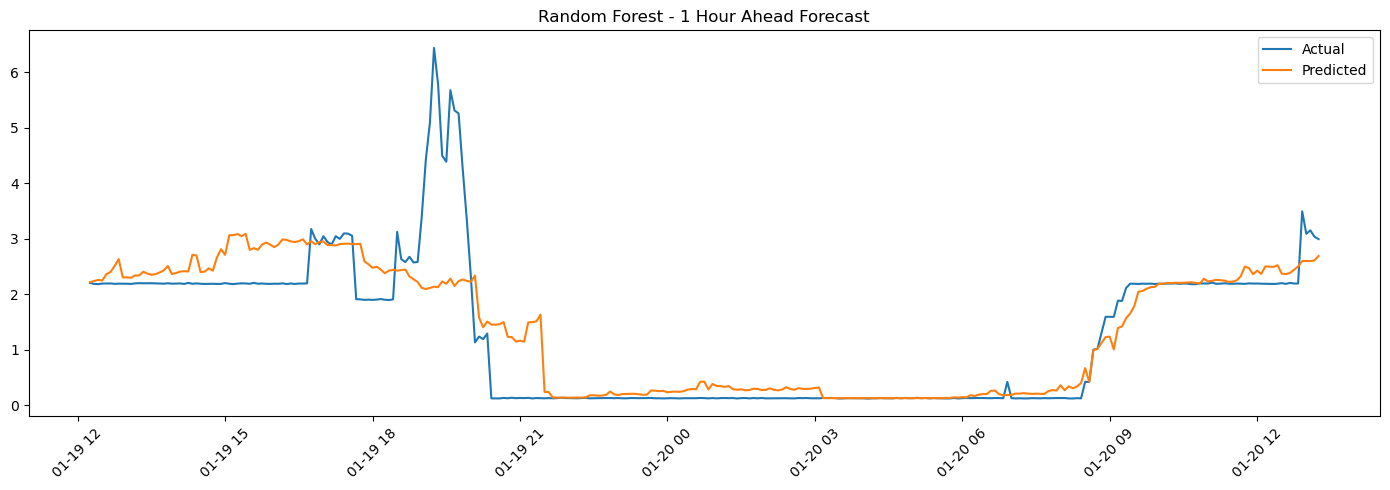

In [10]:
import matplotlib.pyplot as plt

pred_1h = results_1h["predictions"]

plt.figure(figsize=(14,5))
plt.plot(pred_1h.index[:300], pred_1h["y_true"].iloc[:300], label="Actual")
plt.plot(pred_1h.index[:300], pred_1h["y_pred"].iloc[:300], label="Predicted")
plt.legend()
plt.title("Random Forest - 1 Hour Ahead Forecast")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

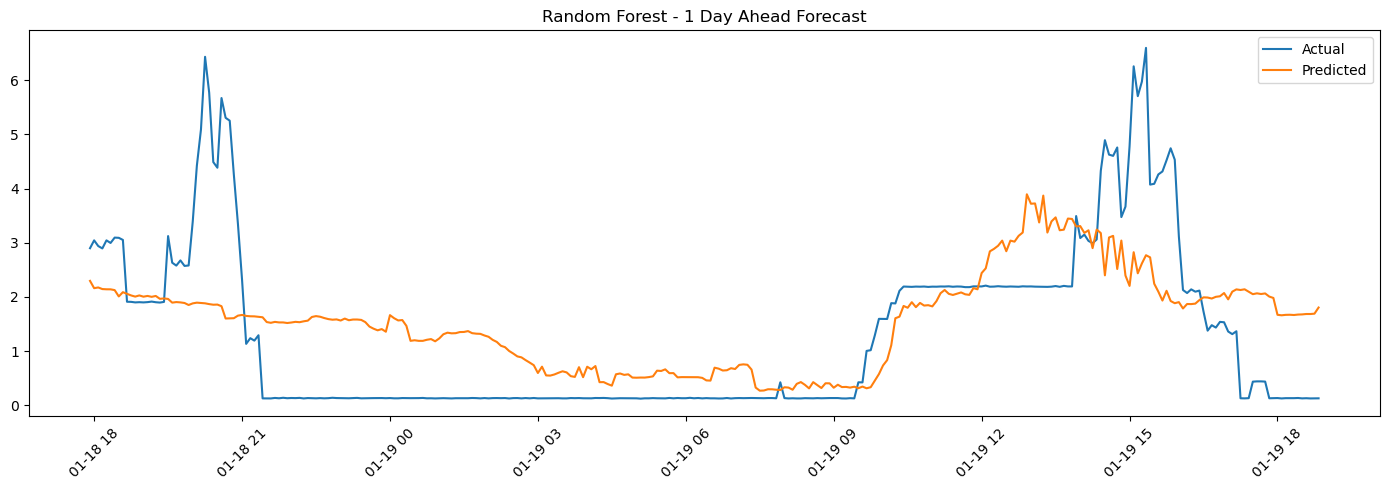

In [11]:
pred_1d = results_1d["predictions"]

plt.figure(figsize=(14,5))
plt.plot(pred_1d.index[:300], pred_1d["y_true"].iloc[:300], label="Actual")
plt.plot(pred_1d.index[:300], pred_1d["y_pred"].iloc[:300], label="Predicted")
plt.legend()
plt.title("Random Forest - 1 Day Ahead Forecast")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()